# COEP Technological University
## Artificial Intelligence - Lab Assignment 4
### Machine Learning Clustering

**Name**: Arnav Singhal\
**MIS**: 612203012\
**Div**: 1 | **Batch**: T3


## 1. Introduction

**Dataset:** Periodic Labour Force Survey (PLFS) 2025 - Household Level Data, MoSPI

**Problem Statement:** Cluster Indian households into economically distinct groups using
household-level expenditure, income, and demographic features from the PLFS 2025 survey
(Calendar Year 2025, First Visit). The objective is to discover natural patterns in household
economic behaviour across rural and urban India without relying on predefined income classes.

**Why clustering?**
- No labelled income-group ground truth exists at this granularity.
- Household economic profiles are driven by complex interactions between expenditure
  categories, household composition, and income sources that simple binning cannot capture.
- Clusters can inform targeted welfare schemes and policy design.

**Dataset Justification:**

| Field | Details |
|---|---|
| Dataset Name | PLFS 2025 Household Level Data (First Visit) |
| Source | MoSPI via mospi.gov.in |
| Format | CSV |
| Rows | 24,475 |
| Columns | 16 |
| Numerical Features | HH_Size, Exp_Goods_Services, Exp_Home_Grown, Total_Monthly_Exp, Rent_Income, Interest_Income, Pension_Income, Total_Income |
| Categorical Features | Quarter, Sector, State, HH_Type, Religion, Social_Group, Land_Code |
| Date Range | Q1–Q4, Calendar Year 2025 |
| Suitability | Rich mix of expenditure and income streams; no natural labels; > 500 rows; > 5 numerical features |
| Expected best algorithm | K-Means: expenditure features are roughly Gaussian after log-transform; the elbow method should yield a clear K; interpretable centroids map directly to economic tiers |


## 2. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors, NearestCentroid, KNeighborsClassifier
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from kneed import KneeLocator
import joblib, os
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All libraries loaded successfully.')


All libraries loaded successfully.


## 3. Data Acquisition & Loading

The dataset is the PLFS 2025 Household Level (First Visit) microdata from MoSPI.
State codes are decoded using the official state code reference file.


In [2]:
df_raw = pd.read_csv('PLFS_2025_Household.csv')
states = pd.read_excel('Indian_States_and_UTs_Code_Name.xlsx')

# Decode state codes for interpretability
state_map = dict(zip(states['State Code'], states['State/UT Name']))
df_raw['State_Name'] = df_raw['State'].map(state_map)

print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
print()
display(df_raw.head())
print()
print('Data types:')
print(df_raw.dtypes)
print()
print('Basic statistics:')
display(df_raw.describe().round(0))


Shape: (24475, 17)
Columns: ['Quarter', 'Sector', 'State', 'Response_Code', 'HH_Size', 'HH_Type', 'Religion', 'Social_Group', 'Exp_Goods_Services', 'Exp_Home_Grown', 'Total_Monthly_Exp', 'Land_Code', 'Rent_Income', 'Interest_Income', 'Pension_Income', 'Total_Income', 'State_Name']



,Quarter,Sector,State,Response_Code,HH_Size,HH_Type,Religion,Social_Group,Exp_Goods_Services,Exp_Home_Grown,Total_Monthly_Exp,Land_Code,Rent_Income,Interest_Income,Pension_Income,Total_Income,State_Name
0,Q1,1,9,1,7,1,1,3,8500,3000,14458,1,0,200,0,700,Uttar Pradesh
1,Q1,1,6,1,5,5,1,2,8500,0,9708,1,0,100,0,100,Haryana
2,Q1,1,24,1,6,1,1,9,25000,6500,32400,1,0,0,1250,1250,Gujarat
3,Q1,1,8,1,4,1,1,2,5000,2000,8433,1,0,0,1500,1500,Rajasthan
4,Q1,1,19,1,5,5,1,9,6800,310,8145,1,0,0,0,2000,West Bengal



Data types:
Quarter                 str
Sector                int64
State                 int64
Response_Code         int64
HH_Size               int64
HH_Type               int64
Religion              int64
Social_Group          int64
Exp_Goods_Services    int64
Exp_Home_Grown        int64
Total_Monthly_Exp     int64
Land_Code             int64
Rent_Income           int64
Interest_Income       int64
Pension_Income        int64
Total_Income          int64
State_Name              str
dtype: object

Basic statistics:


,Sector,State,Response_Code,HH_Size,HH_Type,Religion,Social_Group,Exp_Goods_Services,Exp_Home_Grown,Total_Monthly_Exp,Land_Code,Rent_Income,Interest_Income,Pension_Income,Total_Income
count,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0,24475.0
mean,1.0,19.0,1.0,4.0,3.0,1.0,4.0,11358.0,808.0,14461.0,1.0,641.0,342.0,2071.0,4771.0
std,0.0,10.0,0.0,2.0,2.0,1.0,3.0,7614.0,1400.0,9122.0,1.0,3617.0,1157.0,8076.0,10560.0
min,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,450.0,1.0,0.0,0.0,0.0,0.0
25%,1.0,9.0,1.0,3.0,1.0,1.0,2.0,6500.0,0.0,8808.0,1.0,0.0,0.0,0.0,129.0
50%,1.0,20.0,1.0,4.0,2.0,1.0,3.0,9500.0,0.0,12450.0,1.0,0.0,100.0,0.0,1220.0
75%,2.0,27.0,1.0,5.0,3.0,1.0,9.0,15000.0,1200.0,17783.0,1.0,0.0,240.0,0.0,3675.0
max,2.0,37.0,1.0,19.0,9.0,9.0,9.0,155000.0,20000.0,181917.0,12.0,160000.0,80000.0,150000.0,200000.0


In [3]:
# Class distribution of key categorical variables
print('Quarter distribution:')
print(df_raw['Quarter'].value_counts())
print()
print('Sector (1=Rural, 2=Urban):')
print(df_raw['Sector'].value_counts())
print()
print('HH_Type (1=Self-employed Agri, 2=Self-employed Non-Agri,')
print('         3=Regular Wage, 4=Casual Labour Agri, 5=Casual Labour Non-Agri, 9=Others):')
print(df_raw['HH_Type'].value_counts().sort_index())
print()
print('Social_Group (1=ST, 2=SC, 3=OBC, 9=Others):')
print(df_raw['Social_Group'].value_counts().sort_index())


Quarter distribution:
Quarter
Q3    6186
Q4    6162
Q2    6141
Q1    5986
Name: count, dtype: int64

Sector (1=Rural, 2=Urban):
Sector
1    13423
2    11052
Name: count, dtype: int64

HH_Type (1=Self-employed Agri, 2=Self-employed Non-Agri,
         3=Regular Wage, 4=Casual Labour Agri, 5=Casual Labour Non-Agri, 9=Others):
HH_Type
1    9307
2    7102
3    3415
4     852
5    1750
9    2049
Name: count, dtype: int64

Social_Group (1=ST, 2=SC, 3=OBC, 9=Others):
Social_Group
1     2548
2     4236
3    11276
9     6415
Name: count, dtype: int64


## 4. Preprocessing & Feature Engineering

### 4.1 Missing Value Analysis


In [4]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw)) * 100
missing_report = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
missing_report = missing_report[missing_report['Count'] > 0].sort_values('Percentage', ascending=False)

if missing_report.empty:
    print('No missing values found in the dataset.')
else:
    print(missing_report)
    plt.figure(figsize=(12, 5))
    sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
    plt.title('Missing Value Pattern')
    plt.tight_layout(); plt.savefig('missing_pattern.png', dpi=150); plt.show()


No missing values found in the dataset.


### 4.2 Feature Engineering

We derive six clustering-relevant features from the raw columns.


In [5]:
df = df_raw.copy()

# Ratio of non-goods expenditure to total (home-grown share)
df['Home_Grown_Share'] = df['Exp_Home_Grown'] / (df['Total_Monthly_Exp'] + 1)

# Non-labour income (passive income: rent + interest + pension)
df['Passive_Income'] = df['Rent_Income'] + df['Interest_Income'] + df['Pension_Income']

# Income to expenditure ratio (savings proxy; capped to avoid div-by-zero)
df['Income_Exp_Ratio'] = df['Total_Income'] / (df['Total_Monthly_Exp'] + 1)

# Decoding categorical labels for later use
sector_map   = {1: 'Rural', 2: 'Urban'}
hhtype_map   = {1: 'Self-Emp-Agri', 2: 'Self-Emp-NonAgri', 3: 'Regular-Wage',
                4: 'Casual-Agri', 5: 'Casual-NonAgri', 9: 'Others'}
sg_map       = {1: 'ST', 2: 'SC', 3: 'OBC', 9: 'Others'}

df['Sector_Label']   = df['Sector'].map(sector_map)
df['HH_Type_Label']  = df['HH_Type'].map(hhtype_map)
df['SG_Label']       = df['Social_Group'].map(sg_map)

print('New features added: Home_Grown_Share, Passive_Income, Income_Exp_Ratio')
print('Shape after engineering:', df.shape)
display(df[['HH_Size','Exp_Goods_Services','Total_Monthly_Exp','Total_Income',
            'Home_Grown_Share','Passive_Income','Income_Exp_Ratio']].describe().round(3))


New features added: Home_Grown_Share, Passive_Income, Income_Exp_Ratio
Shape after engineering: (24475, 23)


,HH_Size,Exp_Goods_Services,Total_Monthly_Exp,Total_Income,Home_Grown_Share,Passive_Income,Income_Exp_Ratio
count,24475.000,24475.000,24475.000,24475.000,24475.000,24475.000,24475.000
mean,4.241,11358.182,14461.301,4770.984,0.061,3054.176,0.366
std,1.967,7614.219,9121.814,10559.798,0.093,9506.382,0.745
min,1.000,0.000,450.000,0.000,0.000,0.000,0.000
25%,3.000,6500.000,8808.000,129.000,0.000,0.000,0.011
50%,4.000,9500.000,12450.000,1220.000,0.000,177.000,0.097
75%,5.000,15000.000,17783.000,3675.000,0.103,1300.500,0.320
max,19.000,155000.000,181917.000,200000.000,0.462,188000.000,17.448


### 4.3 Outlier Detection & Removal (IQR)

Rows before: 24475 | After outlier removal: 14062 (42.5% removed)


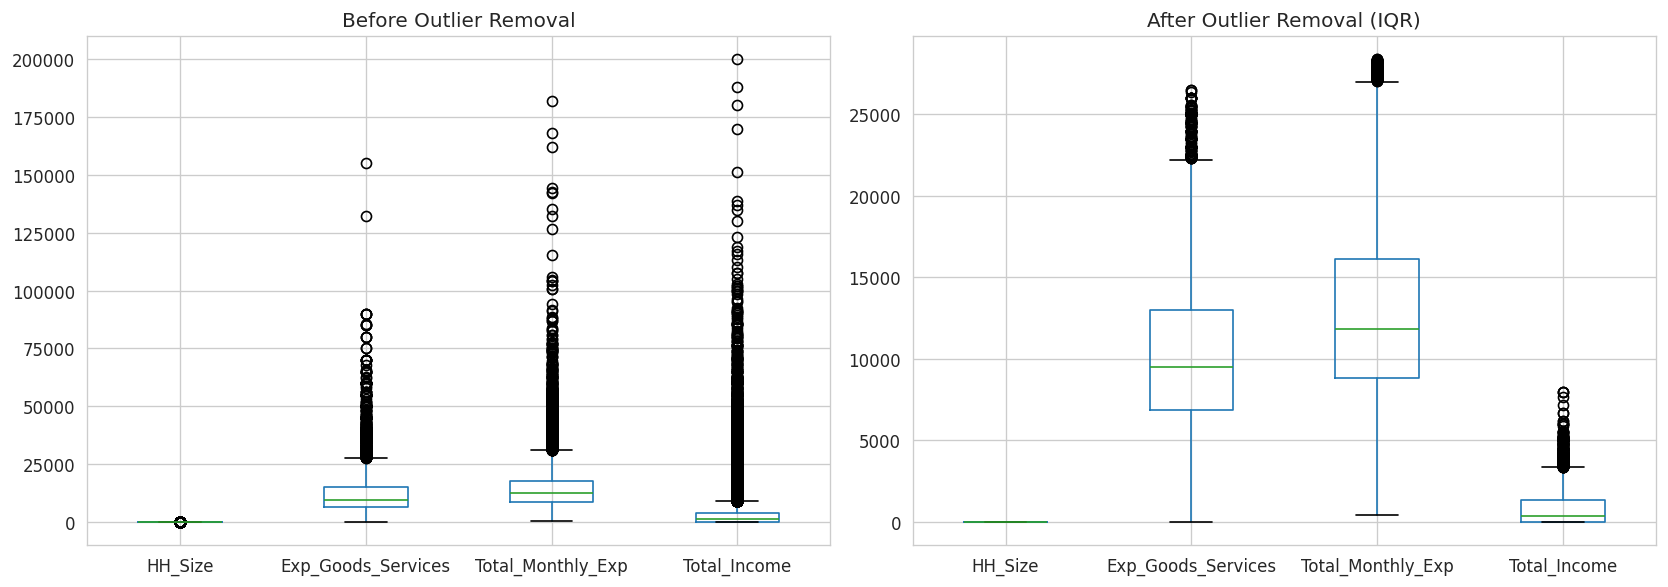

In [6]:
CLUSTER_FEATURES = [
    'HH_Size', 'Exp_Goods_Services', 'Exp_Home_Grown',
    'Total_Monthly_Exp', 'Total_Income',
    'Home_Grown_Share', 'Passive_Income', 'Income_Exp_Ratio'
]

def remove_outliers_iqr(dataframe, cols, factor=1.5):
    df_clean = dataframe.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - factor * IQR, Q3 + factor * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

df_clean = remove_outliers_iqr(df, CLUSTER_FEATURES)
print(f'Rows before: {len(df)} | After outlier removal: {len(df_clean)} '
      f'({100*(len(df)-len(df_clean))/len(df):.1f}% removed)')

# Box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[['HH_Size','Exp_Goods_Services','Total_Monthly_Exp','Total_Income']].boxplot(ax=axes[0])
axes[0].set_title('Before Outlier Removal')
df_clean[['HH_Size','Exp_Goods_Services','Total_Monthly_Exp','Total_Income']].boxplot(ax=axes[1])
axes[1].set_title('After Outlier Removal (IQR)')
plt.tight_layout(); plt.savefig('outliers.png', dpi=150); plt.show()


### 4.4 Feature Scaling

StandardScaler is applied so that features with large monetary ranges (e.g., Total_Income in
thousands of rupees) do not dominate distance calculations over smaller-scale features like HH_Size.


In [7]:
X_raw = df_clean[CLUSTER_FEATURES].values

# First pass: scale all features to identify correlations
_scaler_tmp = StandardScaler()
X_scaled_all = _scaler_tmp.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled_all, columns=CLUSTER_FEATURES)

print('Mean after scaling (should be ~0):')
print(X_scaled_df.mean().round(4))
print()
print('Std after scaling (should be ~1):')
print(X_scaled_df.std().round(4))


Mean after scaling (should be ~0):
HH_Size              -0.0
Exp_Goods_Services    0.0
Exp_Home_Grown       -0.0
Total_Monthly_Exp     0.0
Total_Income         -0.0
Home_Grown_Share      0.0
Passive_Income        0.0
Income_Exp_Ratio      0.0
dtype: float64

Std after scaling (should be ~1):
HH_Size               1.0
Exp_Goods_Services    1.0
Exp_Home_Grown        1.0
Total_Monthly_Exp     1.0
Total_Income          1.0
Home_Grown_Share      1.0
Passive_Income        1.0
Income_Exp_Ratio      1.0
dtype: float64


### 4.5 Feature Selection (Correlation Filter)

Features with pairwise absolute correlation > 0.90 are dropped to reduce redundancy.


Dropped 2 highly correlated features: ['Total_Monthly_Exp', 'Home_Grown_Share']
Remaining features (6): ['HH_Size', 'Exp_Goods_Services', 'Exp_Home_Grown', 'Total_Income', 'Passive_Income', 'Income_Exp_Ratio']


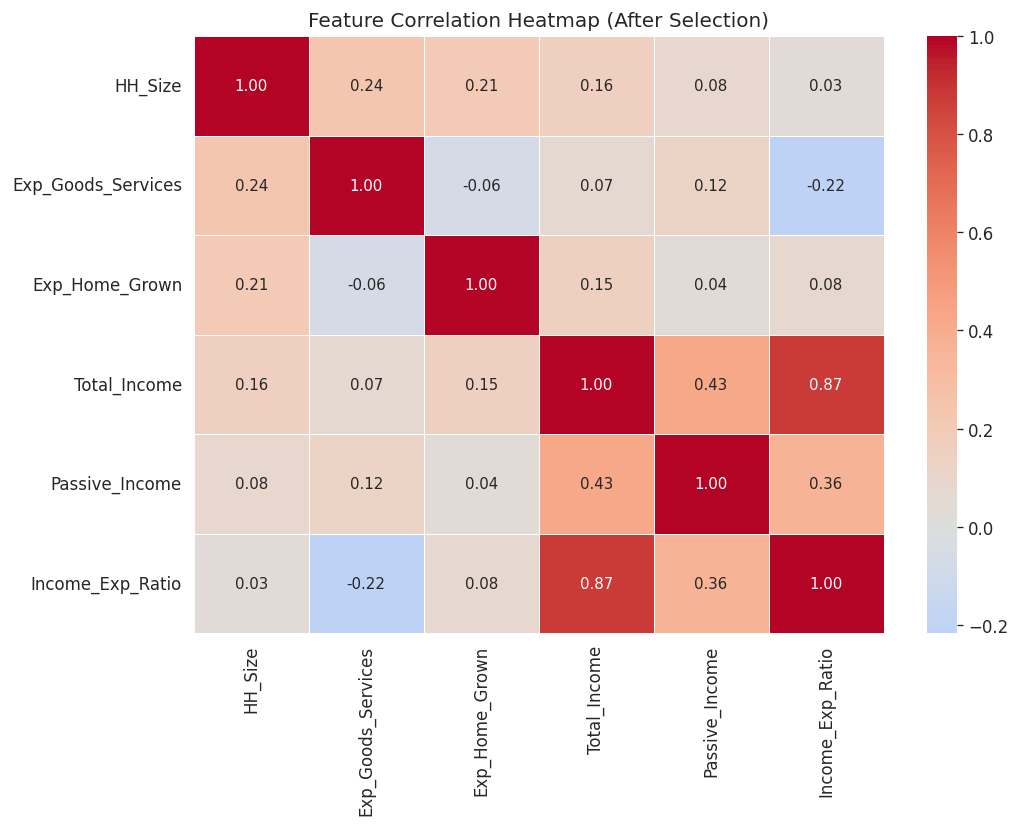

In [8]:
corr_matrix = X_scaled_df.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.90)]

X_selected_df = X_scaled_df.drop(columns=to_drop)
feature_cols   = X_selected_df.columns.tolist()
print(f'Dropped {len(to_drop)} highly correlated features: {to_drop}')
print(f'Remaining features ({len(feature_cols)}): {feature_cols}')

# Refit scaler ONLY on the selected raw features so model bundle is self-consistent
X_raw_selected = df_clean[feature_cols].values
scaler = StandardScaler()
X_selected = scaler.fit_transform(X_raw_selected)
X_selected_df = pd.DataFrame(X_selected, columns=feature_cols)

plt.figure(figsize=(9, 7))
sns.heatmap(X_selected_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap (After Selection)')
plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150); plt.show()


### 4.6 PCA for 2-D Visualisation

PCA explained variance: PC1=36.6%  PC2=22.0%  Total=58.6%


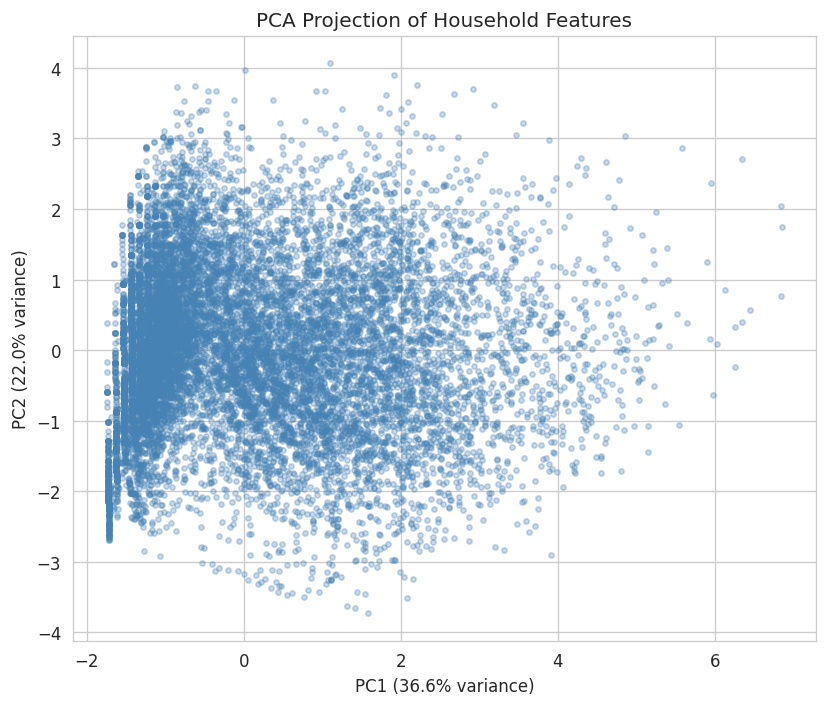

In [9]:
pca_vis = PCA(n_components=2, random_state=42)
X_pca = pca_vis.fit_transform(X_selected)

print(f'PCA explained variance: PC1={pca_vis.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2={pca_vis.explained_variance_ratio_[1]*100:.1f}%  '
      f'Total={sum(pca_vis.explained_variance_ratio_)*100:.1f}%')

plt.figure(figsize=(7, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=10, c='steelblue')
plt.xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA Projection of Household Features')
plt.tight_layout(); plt.savefig('pca_scatter.png', dpi=150); plt.show()


## 5. Exploratory Data Analysis

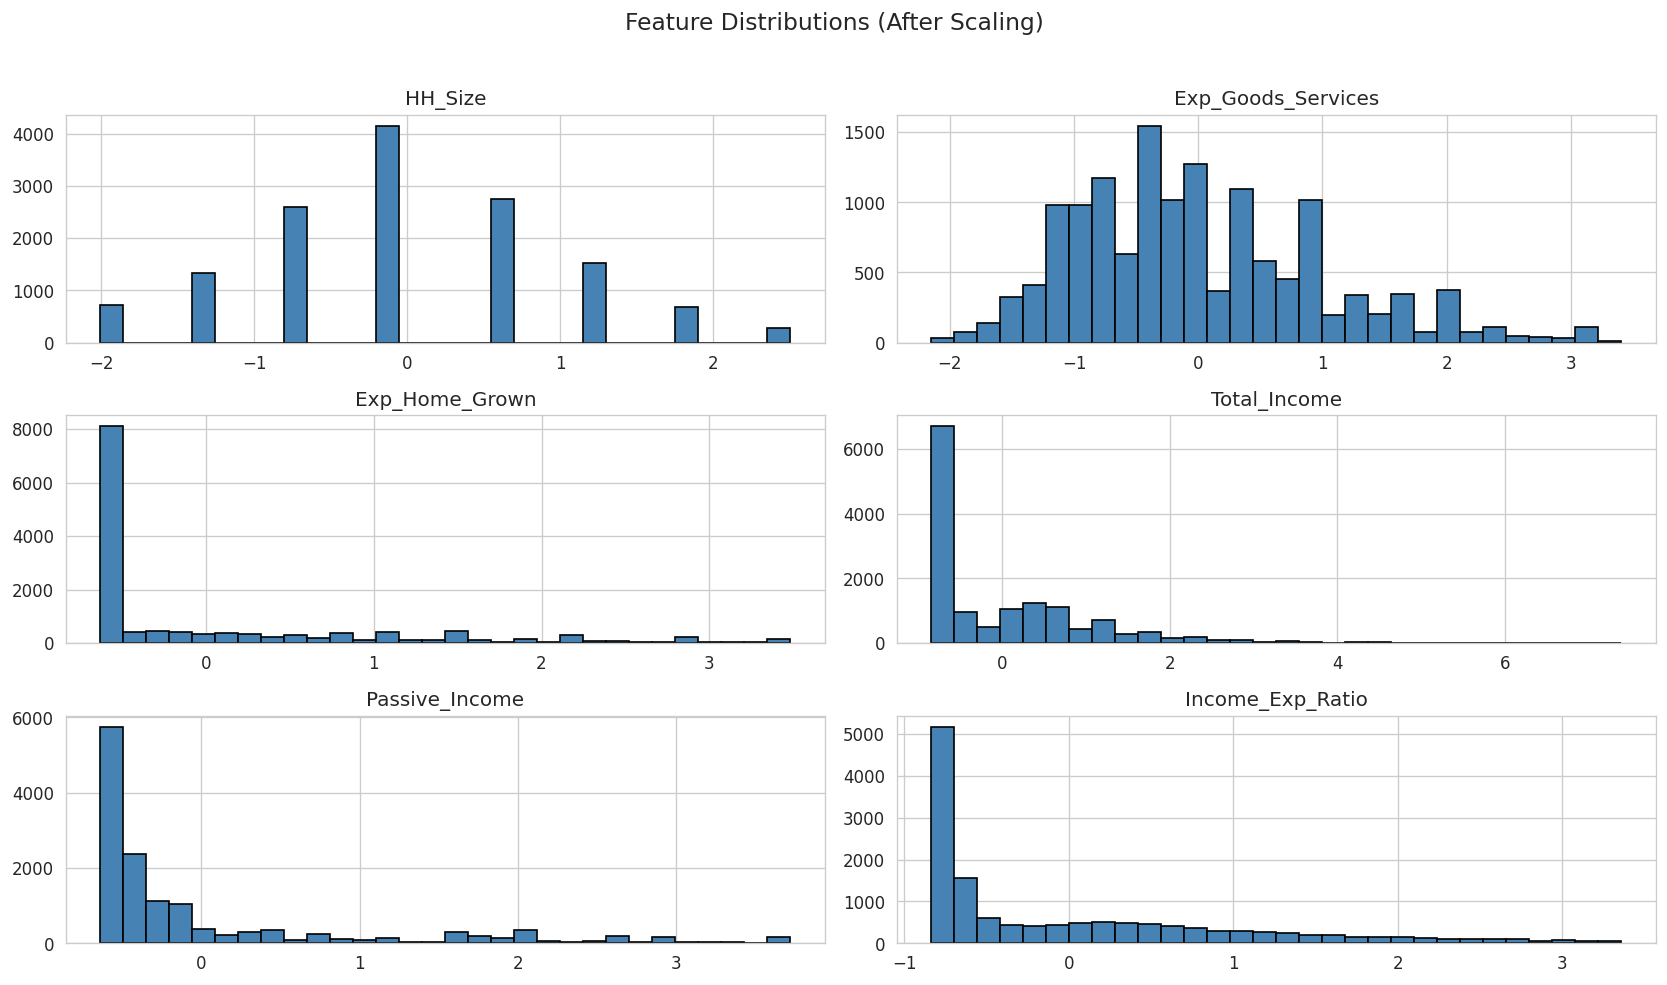

In [10]:
X_selected_df.hist(bins=30, figsize=(14, 8), edgecolor='black', color='steelblue')
plt.suptitle('Feature Distributions (After Scaling)', fontsize=14, y=1.02)
plt.tight_layout(); plt.savefig('histograms.png', dpi=150); plt.show()


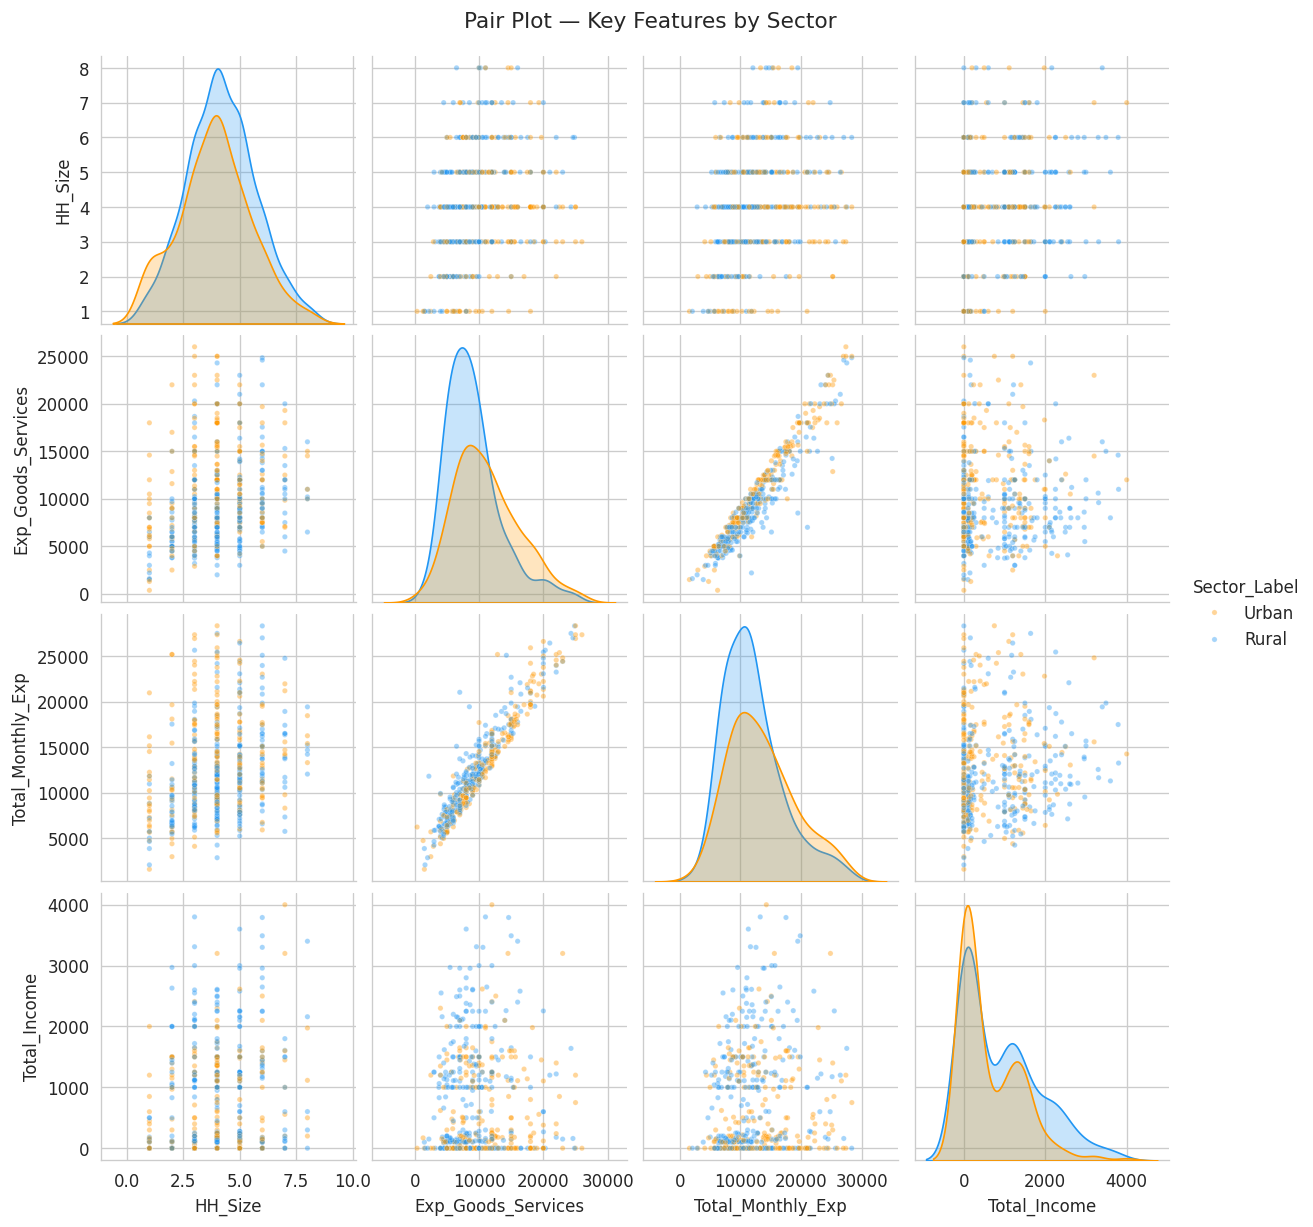

In [11]:
# Pair plot on original (unscaled) features for interpretability
pair_df = df_clean[['HH_Size','Exp_Goods_Services','Total_Monthly_Exp',
                    'Total_Income','Sector_Label']].copy()
sample_pair = pair_df.sample(min(500, len(pair_df)), random_state=42)
g = sns.pairplot(sample_pair, hue='Sector_Label', diag_kind='kde',
                 plot_kws={'alpha': 0.4, 's': 10},
                 palette={'Rural': '#2196F3', 'Urban': '#FF9800'})
g.figure.suptitle('Pair Plot — Key Features by Sector', y=1.02, fontsize=13)
plt.savefig('pairplot.png', dpi=120, bbox_inches='tight'); plt.show()


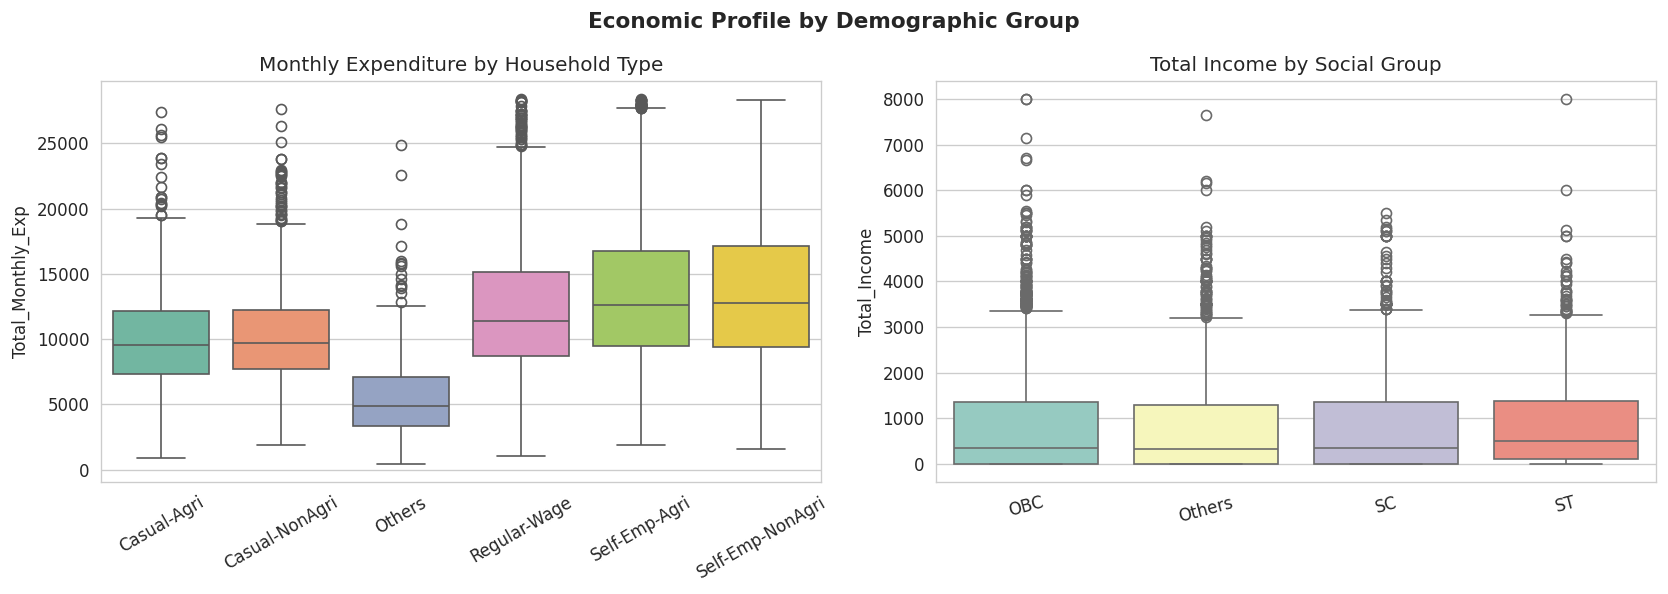

In [12]:
# Expenditure distribution by household type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='HH_Type_Label', y='Total_Monthly_Exp', data=df_clean,
            ax=axes[0], palette='Set2', order=sorted(df_clean['HH_Type_Label'].unique()))
axes[0].set_title('Monthly Expenditure by Household Type')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(x='SG_Label', y='Total_Income', data=df_clean,
            ax=axes[1], palette='Set3',
            order=sorted(df_clean['SG_Label'].unique()))
axes[1].set_title('Total Income by Social Group')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Economic Profile by Demographic Group', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('eda_groups.png', dpi=150); plt.show()


## 6. Train / Test Split

In [13]:
X_train, X_test = train_test_split(
    X_selected, test_size=0.20, random_state=42
)
print(f'Training set: {X_train.shape} | Test set: {X_test.shape}')

# Also keep aligned metadata for post-hoc analysis
df_clean = df_clean.reset_index(drop=True)
train_idx, test_idx = train_test_split(np.arange(len(X_selected)), test_size=0.20, random_state=42)


Training set: (11249, 6) | Test set: (2813, 6)


## 7. Clustering Models

### 7.1 K-Means — Elbow Method


Optimal K detected by elbow method: 5


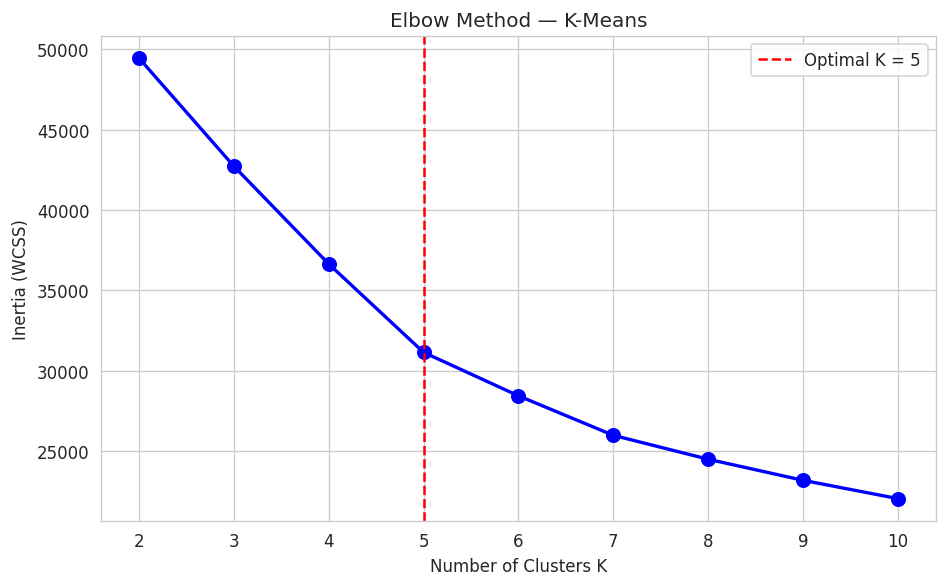

In [14]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_train)
    inertias.append(km.inertia_)

kl = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
optimal_k = kl.elbow
print(f'Optimal K detected by elbow method: {optimal_k}')

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=optimal_k, color='red', linestyle='--', label=f'Optimal K = {optimal_k}')
plt.xlabel('Number of Clusters K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method — K-Means')
plt.legend(); plt.tight_layout()
plt.savefig('elbow_kmeans.png', dpi=150); plt.show()


### 7.2 K-Means - Train with Optimal K

In [15]:
kmeans_model = KMeans(
    n_clusters=optimal_k, init='k-means++', n_init=10,
    max_iter=300, tol=1e-4, random_state=42
)
kmeans_model.fit(X_train)
train_labels_km = kmeans_model.labels_
test_labels_km  = kmeans_model.predict(X_test)

print('K-Means Centroids shape:', kmeans_model.cluster_centers_.shape)
print('Train cluster distribution:')
print(pd.Series(train_labels_km).value_counts().sort_index())


K-Means Centroids shape: (5, 6)
Train cluster distribution:
0    2722
1    1987
2    3611
3    1497
4    1432
Name: count, dtype: int64


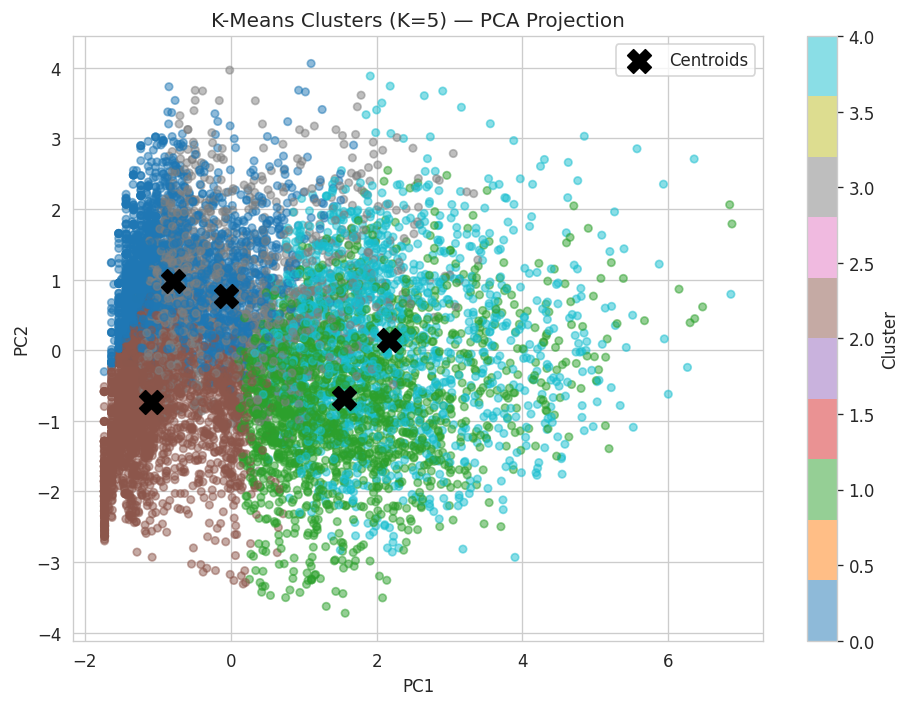

In [16]:
# Visualise K-Means clusters (PCA projection)
pca2 = PCA(n_components=2, random_state=42)
X_train_2d = pca2.fit_transform(X_train)
centroids_2d = pca2.transform(kmeans_model.cluster_centers_)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=train_labels_km, cmap='tab10', alpha=0.5, s=20)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c='black', marker='X', s=200, label='Centroids', zorder=5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'K-Means Clusters (K={optimal_k}) — PCA Projection')
plt.legend(); plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150); plt.show()


### 7.3 Hierarchical Clustering - Dendrogram

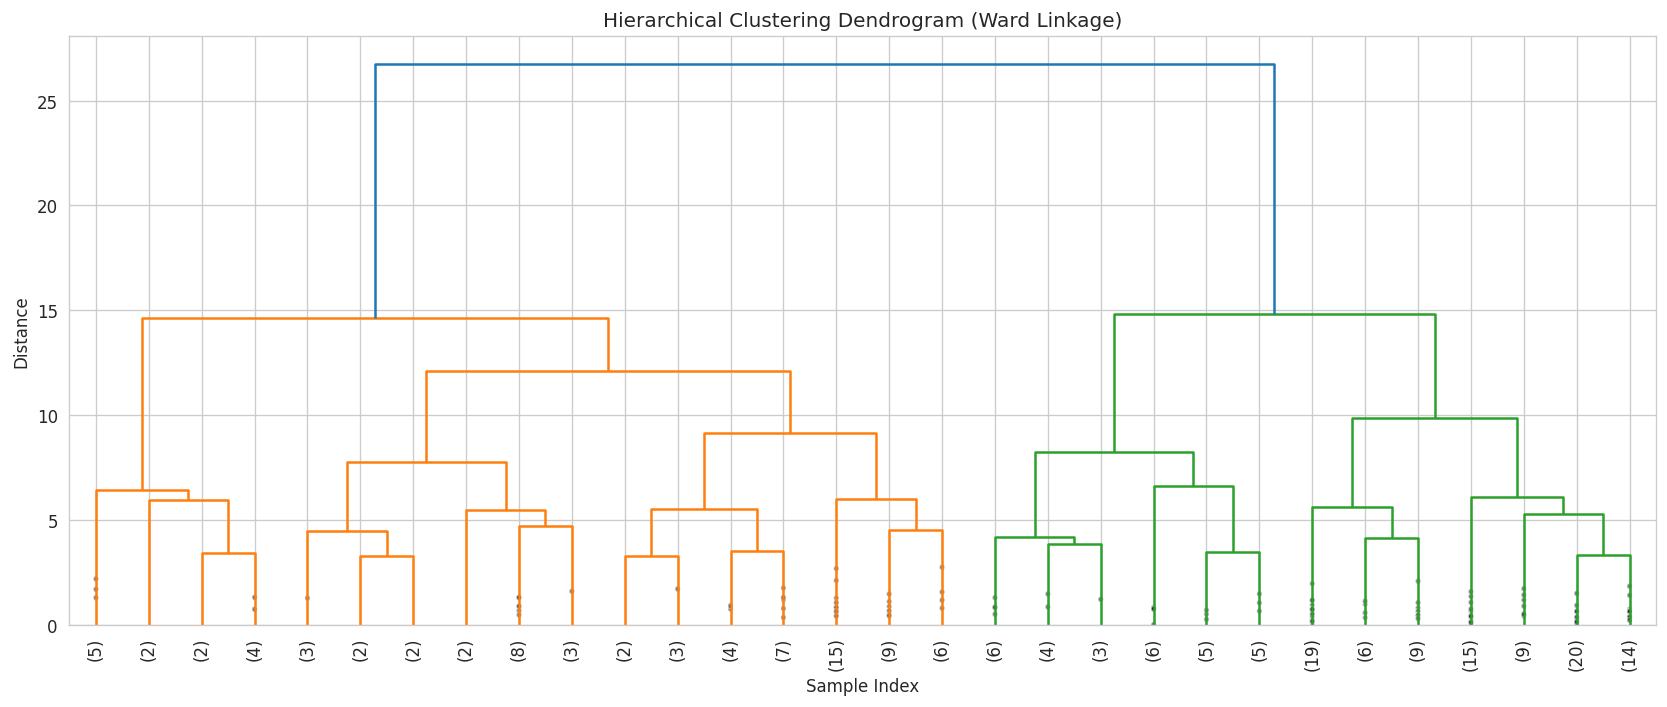

Using K=5 clusters (same as K-Means) for hierarchical clustering.


In [17]:
sample_idx = np.random.RandomState(42).choice(len(X_train), min(200, len(X_train)), replace=False)
X_sample = X_train[sample_idx]
Z = linkage(X_sample, method='ward', metric='euclidean')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0.7 * max(Z[:, 2])
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index'); plt.ylabel('Distance')
plt.tight_layout(); plt.savefig('dendrogram.png', dpi=150); plt.show()
print(f'Using K={optimal_k} clusters (same as K-Means) for hierarchical clustering.')


Hierarchical cluster distribution (train):
0    3155
1    4082
2    1552
3    1519
4     941
Name: count, dtype: int64


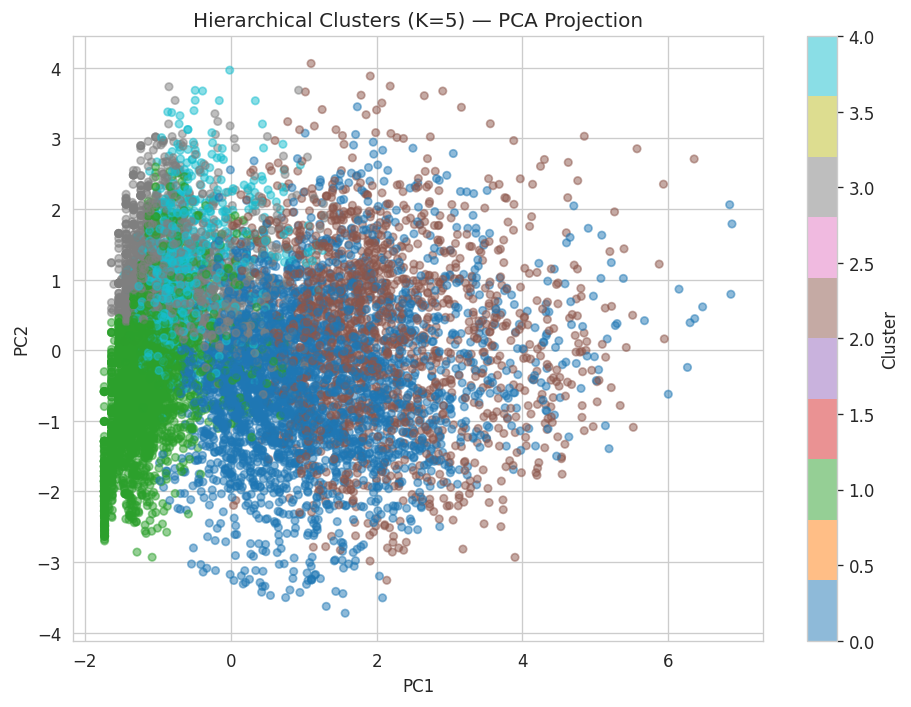

In [18]:
hier_model = AgglomerativeClustering(
    n_clusters=optimal_k, metric='euclidean', linkage='ward'
)
train_labels_hier = hier_model.fit_predict(X_train)

# NearestCentroid for test prediction
nc = NearestCentroid()
nc.fit(X_train, train_labels_hier)
test_labels_hier = nc.predict(X_test)

print('Hierarchical cluster distribution (train):')
print(pd.Series(train_labels_hier).value_counts().sort_index())

# PCA scatter
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=train_labels_hier, cmap='tab10', alpha=0.5, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'Hierarchical Clusters (K={optimal_k}) — PCA Projection')
plt.tight_layout(); plt.savefig('hier_clusters.png', dpi=150); plt.show()


### 7.4 DBSCAN - k-Distance Plot

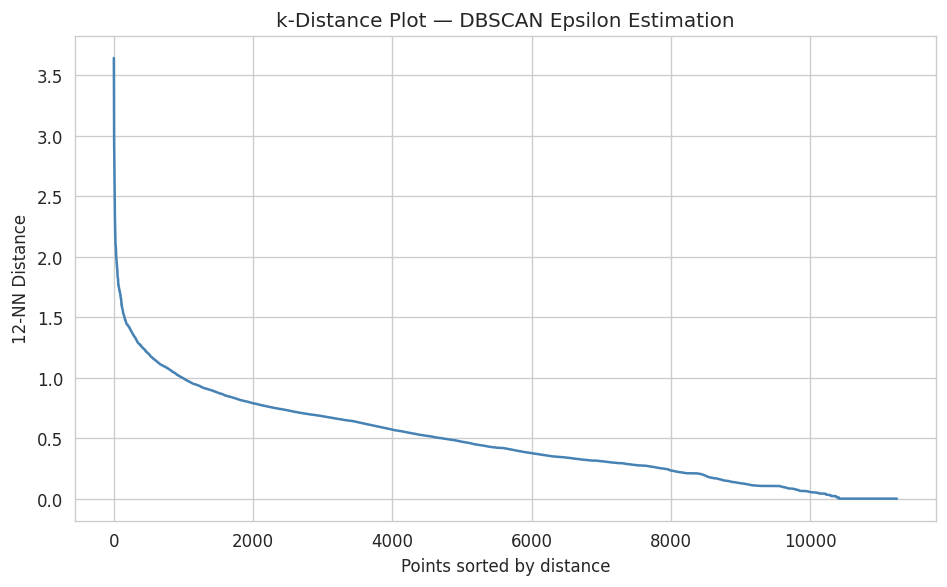

Estimated eps = 1.6  |  min_samples = 12


In [19]:
k_nn = max(5, 2 * X_train.shape[1])
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_train)
distances, _ = nbrs.kneighbors(X_train)
kth_distances = np.sort(distances[:, k_nn - 1])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(kth_distances, linewidth=1.5, color='steelblue')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k_nn}-NN Distance')
plt.title('k-Distance Plot — DBSCAN Epsilon Estimation')
plt.tight_layout(); plt.savefig('kdistance.png', dpi=150); plt.show()

# Estimate epsilon at the elbow of the k-distance plot
kl_db = KneeLocator(range(len(kth_distances)), kth_distances,
                    curve='convex', direction='decreasing')
eps_value = round(float(kth_distances[kl_db.elbow]) if kl_db.elbow else 1.5, 2)
min_samples_db = k_nn
print(f'Estimated eps = {eps_value}  |  min_samples = {min_samples_db}')


Clusters found: 1 | Noise points: 35 (0.3%)
DBSCAN cluster distribution (train, excluding noise):
0    11214
Name: count, dtype: int64


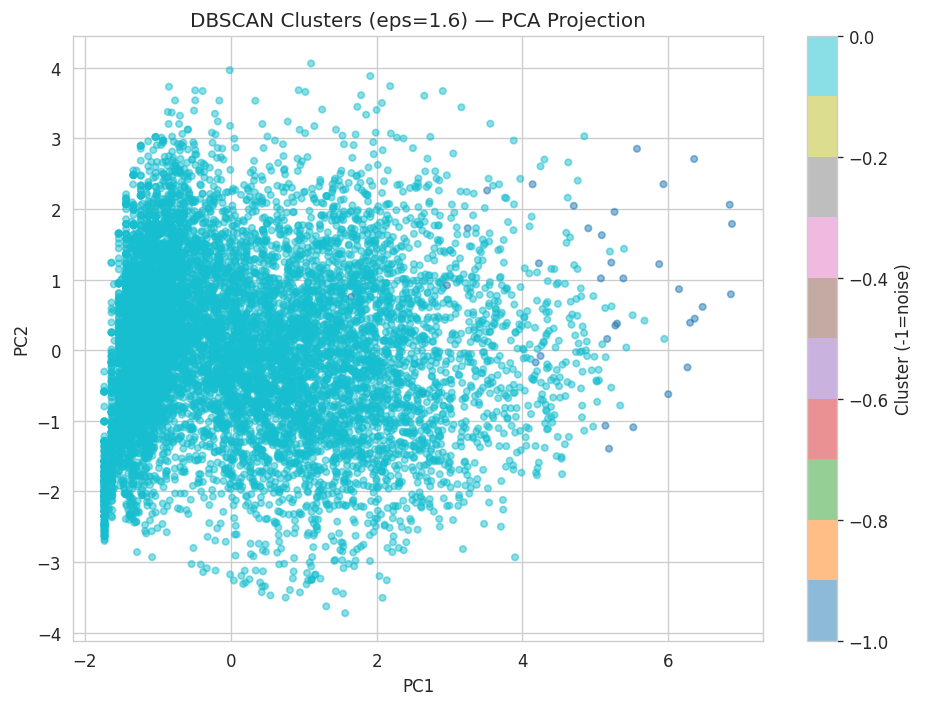

In [20]:
dbscan_model = DBSCAN(eps=eps_value, min_samples=min_samples_db,
                     metric='euclidean', algorithm='auto')
train_labels_db = dbscan_model.fit_predict(X_train)

n_clusters_db = len(set(train_labels_db)) - (1 if -1 in train_labels_db else 0)
n_noise_db    = list(train_labels_db).count(-1)
print(f'Clusters found: {n_clusters_db} | Noise points: {n_noise_db} '
      f'({100*n_noise_db/len(X_train):.1f}%)')

# Predict test labels via 1-NN on non-noise training points
mask_db = train_labels_db != -1
if mask_db.sum() > 0 and n_clusters_db >= 2:
    knn_db = KNeighborsClassifier(n_neighbors=1)
    knn_db.fit(X_train[mask_db], train_labels_db[mask_db])
    test_labels_db = knn_db.predict(X_test)
else:
    test_labels_db = np.zeros(len(X_test), dtype=int)
    print('Warning: DBSCAN produced < 2 clusters. Test labels set to 0.')

print('DBSCAN cluster distribution (train, excluding noise):')
print(pd.Series(train_labels_db[mask_db]).value_counts().sort_index())

# PCA scatter
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=train_labels_db, cmap='tab10', alpha=0.5, s=15)
plt.colorbar(scatter, label='Cluster (-1=noise)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'DBSCAN Clusters (eps={eps_value}) — PCA Projection')
plt.tight_layout(); plt.savefig('dbscan_clusters.png', dpi=150); plt.show()


### 7.5 GMM - BIC / AIC Component Selection

Optimal components by BIC: 10


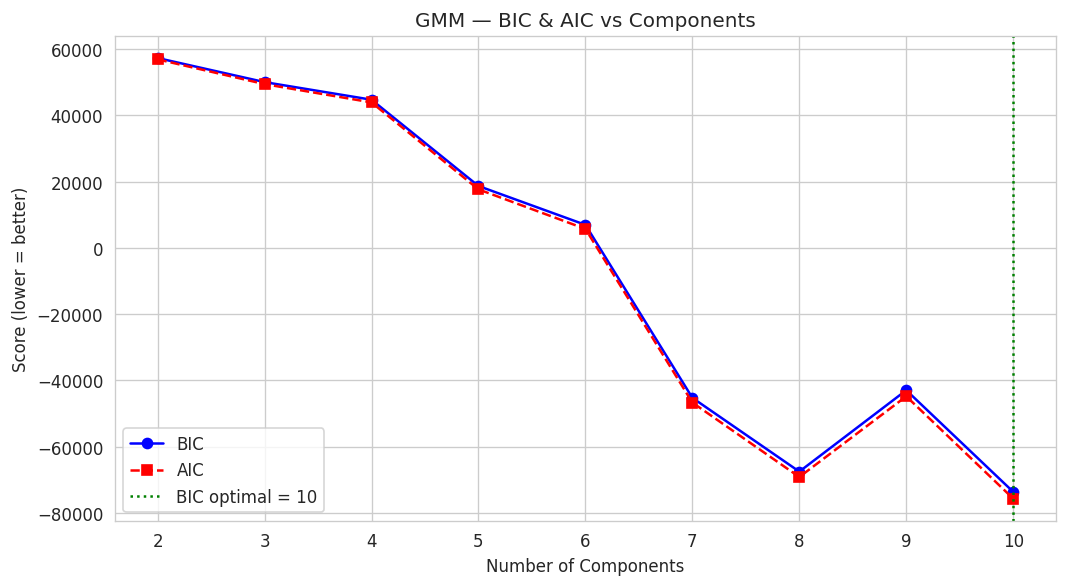

In [21]:
bic_scores, aic_scores = [], []
K_range_gmm = range(2, 11)

for k in K_range_gmm:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          max_iter=200, random_state=42)
    gmm.fit(X_train)
    bic_scores.append(gmm.bic(X_train))
    aic_scores.append(gmm.aic(X_train))

optimal_k_gmm = list(K_range_gmm)[bic_scores.index(min(bic_scores))]
print(f'Optimal components by BIC: {optimal_k_gmm}')

plt.figure(figsize=(9, 5))
plt.plot(K_range_gmm, bic_scores, 'bo-', label='BIC')
plt.plot(K_range_gmm, aic_scores, 'rs--', label='AIC')
plt.axvline(x=optimal_k_gmm, color='green', linestyle=':', label=f'BIC optimal = {optimal_k_gmm}')
plt.xlabel('Number of Components'); plt.ylabel('Score (lower = better)')
plt.title('GMM — BIC & AIC vs Components')
plt.legend(); plt.tight_layout()
plt.savefig('gmm_bic_aic.png', dpi=150); plt.show()


GMM means shape: (10, 6)
GMM cluster distribution (train):
0    2536
1     314
2    1422
3    1018
4     761
5     380
6    1932
7     308
8     723
9    1855
Name: count, dtype: int64


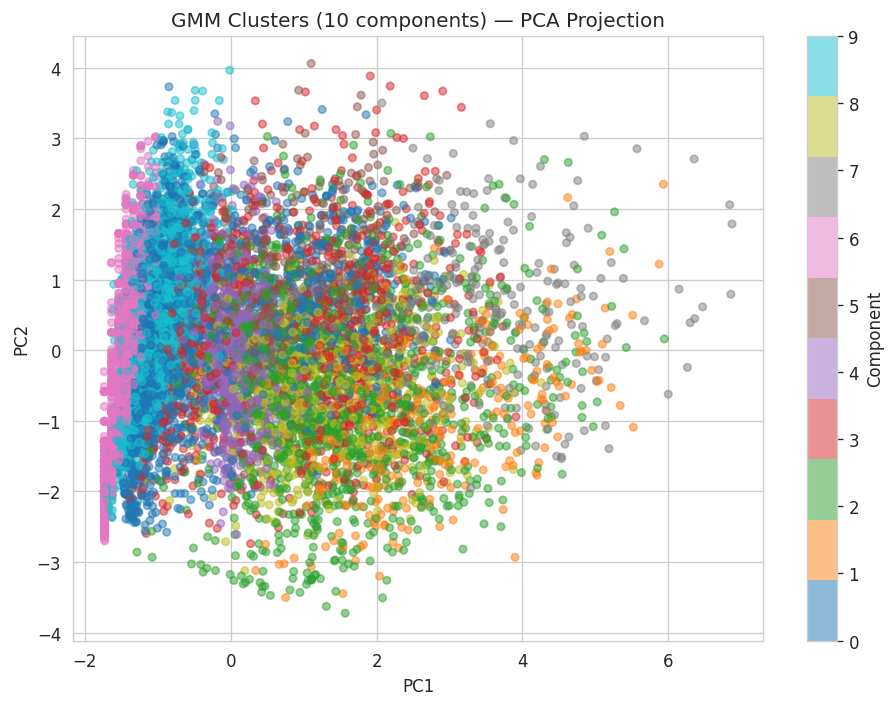

In [22]:
gmm_model = GaussianMixture(
    n_components=optimal_k_gmm, covariance_type='full',
    max_iter=200, n_init=5, random_state=42
)
gmm_model.fit(X_train)
train_labels_gmm = gmm_model.predict(X_train)
test_labels_gmm  = gmm_model.predict(X_test)
train_proba_gmm  = gmm_model.predict_proba(X_train)

print('GMM means shape:', gmm_model.means_.shape)
print('GMM cluster distribution (train):')
print(pd.Series(train_labels_gmm).value_counts().sort_index())

# PCA scatter
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                      c=train_labels_gmm, cmap='tab10', alpha=0.5, s=20)
plt.colorbar(scatter, label='Component')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'GMM Clusters ({optimal_k_gmm} components) — PCA Projection')
plt.tight_layout(); plt.savefig('gmm_clusters.png', dpi=150); plt.show()


## 8. Evaluation and Metrics

In [23]:
def evaluate_clustering(X, labels, model=None, name='Model'):
    result = {'Algorithm': name}
    mask = labels != -1
    X_eval, y_eval = X[mask], labels[mask]
    if len(set(y_eval)) < 2:
        print(f'{name}: Only 1 cluster found, metrics not defined.')
        return result
    result['Silhouette']          = silhouette_score(X_eval, y_eval, sample_size=2000, random_state=42)
    result['Davies-Bouldin']      = davies_bouldin_score(X_eval, y_eval)
    result['Calinski-Harabasz']   = calinski_harabasz_score(X_eval, y_eval)
    if hasattr(model, 'inertia_'):
        result['Inertia (WCSS)']  = model.inertia_
    if hasattr(model, 'score'):
        result['Log-Likelihood']  = model.score(X) * len(X)
    return result

# Training set metrics
metrics_train = [
    evaluate_clustering(X_train, train_labels_km,   kmeans_model, 'K-Means'),
    evaluate_clustering(X_train, train_labels_hier,  None,         'Hierarchical'),
    evaluate_clustering(X_train, train_labels_db,    dbscan_model, 'DBSCAN'),
    evaluate_clustering(X_train, train_labels_gmm,   gmm_model,    'GMM'),
]
metrics_train_df = pd.DataFrame(metrics_train).set_index('Algorithm')
print('=> Training Set Metrics')
display(metrics_train_df.round(4))

# Test set metrics
metrics_test = [
    evaluate_clustering(X_test, test_labels_km,   kmeans_model, 'K-Means'),
    evaluate_clustering(X_test, test_labels_hier,  None,         'Hierarchical'),
    evaluate_clustering(X_test, test_labels_db,    None,         'DBSCAN'),
    evaluate_clustering(X_test, test_labels_gmm,   gmm_model,    'GMM'),
]
metrics_test_df = pd.DataFrame(metrics_test).set_index('Algorithm')
print('\n=> Test Set Metrics')
display(metrics_test_df.round(4))


DBSCAN: Only 1 cluster found, metrics not defined.
=> Training Set Metrics


,Silhouette,Davies-Bouldin,Calinski-Harabasz,Inertia (WCSS),Log-Likelihood
Algorithm,,,,,
K-Means,0.2437,1.3151,3314.9111,31130.1647,-3.501832e+08
Hierarchical,0.1915,1.3996,2554.9794,NaN,NaN
DBSCAN,NaN,NaN,NaN,NaN,NaN
GMM,0.0304,2.2018,916.8670,NaN,4.190436e+04


DBSCAN: Only 1 cluster found, metrics not defined.

=> Test Set Metrics


,Silhouette,Davies-Bouldin,Calinski-Harabasz,Inertia (WCSS),Log-Likelihood
Algorithm,,,,,
K-Means,0.2421,1.2915,825.8891,31130.1647,-2.143673e+07
Hierarchical,0.2439,1.2874,798.0161,NaN,NaN
DBSCAN,NaN,NaN,NaN,NaN,NaN
GMM,0.0227,2.1553,223.3390,NaN,1.071249e+04


### 8.1 Metric Comparison Bar Chart

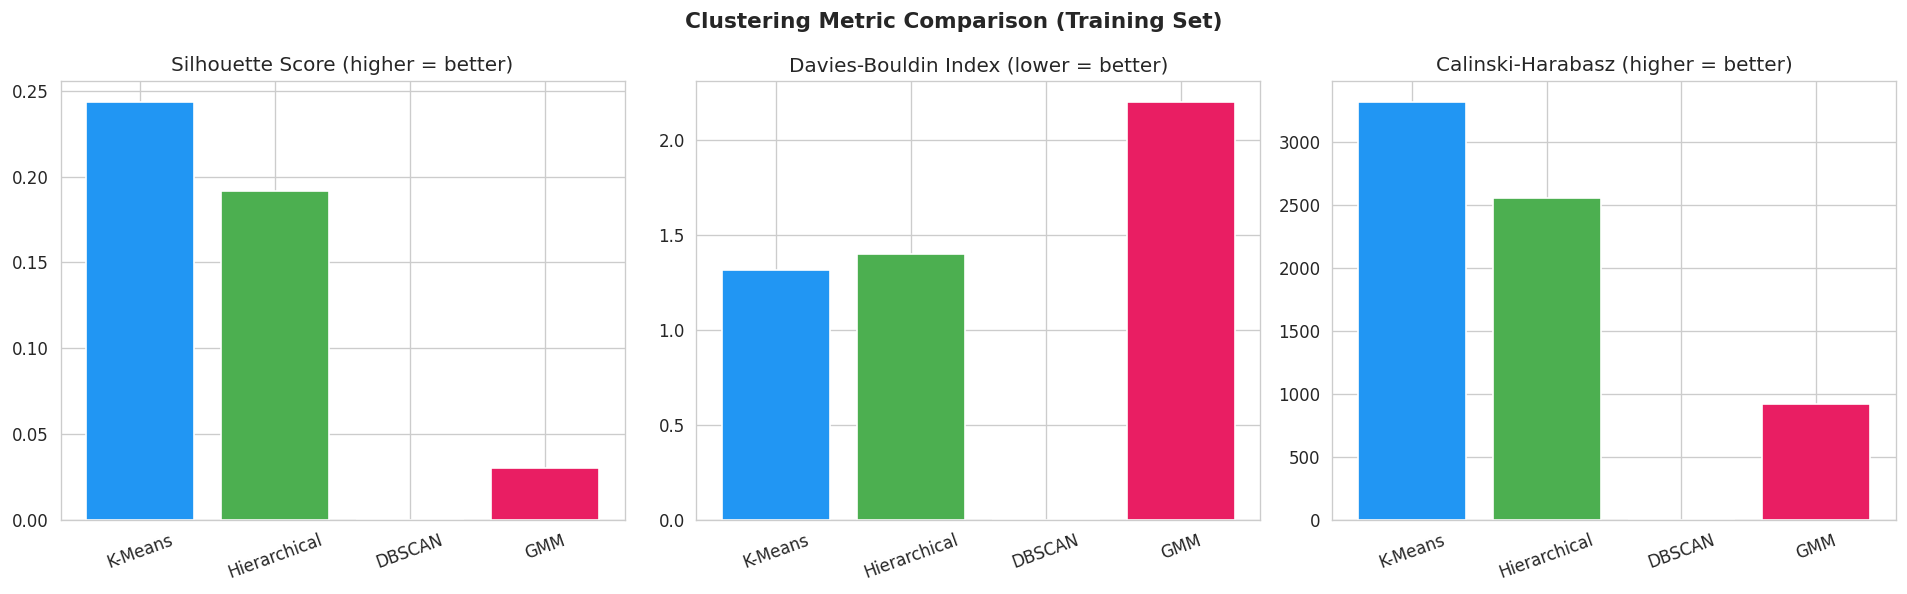

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
algos = metrics_train_df.index.tolist()

# Silhouette
axes[0].bar(algos, metrics_train_df['Silhouette'].fillna(0), color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[0].set_title('Silhouette Score (higher = better)'); axes[0].tick_params(axis='x', rotation=20)

# Davies-Bouldin
axes[1].bar(algos, metrics_train_df['Davies-Bouldin'].fillna(0), color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[1].set_title('Davies-Bouldin Index (lower = better)'); axes[1].tick_params(axis='x', rotation=20)

# Calinski-Harabasz
axes[2].bar(algos, metrics_train_df['Calinski-Harabasz'].fillna(0), color=['#2196F3','#4CAF50','#FF9800','#E91E63'])
axes[2].set_title('Calinski-Harabasz (higher = better)'); axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Clustering Metric Comparison (Training Set)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('metric_comparison.png', dpi=150); plt.show()


## 9. Hyperparameter Tuning

In [25]:
# K-Means: tune K and init strategy
km_results = []
for k in range(2, 9):
    for init in ['k-means++', 'random']:
        m = KMeans(n_clusters=k, init=init, n_init=10, random_state=42)
        labels = m.fit_predict(X_train)
        sil = silhouette_score(X_train, labels, sample_size=2000, random_state=42)
        km_results.append({'K': k, 'init': init, 'Inertia': m.inertia_, 'Silhouette': sil})

km_tune_df = pd.DataFrame(km_results)
print('K-Means tuning results:')
display(km_tune_df.sort_values('Silhouette', ascending=False).head(8))
best_km_row = km_tune_df.loc[km_tune_df['Silhouette'].idxmax()]
print(f'\nBest K-Means config: K={int(best_km_row.K)}, init={best_km_row.init}, Silhouette={best_km_row.Silhouette:.4f}')


K-Means tuning results:


,K,init,Inertia,Silhouette
0,2,k-means++,49459.841257,0.301879
1,2,random,49459.767831,0.301595
5,4,random,36635.846637,0.288800
4,4,k-means++,36635.763278,0.288418
3,3,random,42726.807923,0.267877
2,3,k-means++,42726.726632,0.267358
7,5,random,31130.294702,0.243802
6,5,k-means++,31130.164746,0.243689



Best K-Means config: K=2, init=k-means++, Silhouette=0.3019


In [26]:
# DBSCAN: tune eps and min_samples
db_results = []
for eps in [0.3, 0.5, 0.8, 1.0, 1.5, 2.0]:
    for ms in [5, 10, 15, 20]:
        m = DBSCAN(eps=eps, min_samples=ms)
        labels = m.fit_predict(X_train)
        n_cls = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_cls >= 2:
            mask = labels != -1
            sil = silhouette_score(X_train[mask], labels[mask], sample_size=2000, random_state=42)
            db_results.append({'eps': eps, 'min_samples': ms,
                                'n_clusters': n_cls, 'noise_%': round(100*n_noise/len(X_train),1),
                                'Silhouette': sil})

if db_results:
    db_tune_df = pd.DataFrame(db_results)
    print('DBSCAN tuning results (top 10 by silhouette):')
    display(db_tune_df.sort_values('Silhouette', ascending=False).head(10))
    best_db_row = db_tune_df.loc[db_tune_df['Silhouette'].idxmax()]
    print(f'\nBest DBSCAN config: eps={best_db_row.eps}, min_samples={int(best_db_row.min_samples)}, '
          f'Silhouette={best_db_row.Silhouette:.4f}')
else:
    print('No DBSCAN config produced >= 2 clusters.')


DBSCAN tuning results (top 10 by silhouette):


,eps,min_samples,n_clusters,noise_%,Silhouette
9,0.8,10,3,8.5,0.388727
12,1.0,5,5,1.7,0.319461
10,0.8,15,2,11.2,0.296715
11,0.8,20,2,13.7,0.256536
8,0.8,5,9,5.2,0.224079
3,0.3,20,13,65.0,0.082991
2,0.3,15,27,59.6,0.071517
7,0.5,20,16,41.4,0.065930
1,0.3,10,27,51.3,0.039763
6,0.5,15,26,36.4,0.020550



Best DBSCAN config: eps=0.8, min_samples=10, Silhouette=0.3887


### 9.1 Bootstrap Stability Analysis (K-Means)

K-Means Bootstrap ARI: mean=0.980  std=0.013
Interpretation: ARI > 0.8 indicates high cluster stability.


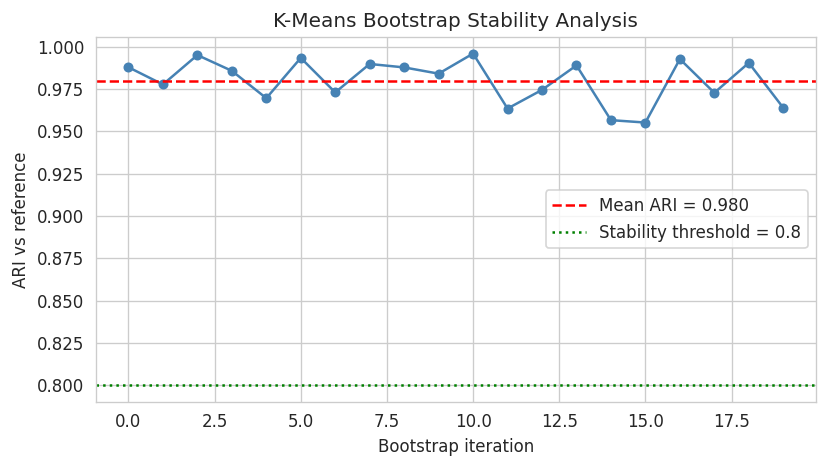

In [27]:
N_BOOTSTRAP = 20
SUBSAMPLE   = 0.8
ari_scores_km = []

ref_model  = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=0)
ref_labels = ref_model.fit_predict(X_train)

for i in range(N_BOOTSTRAP):
    idx    = np.random.RandomState(i).choice(len(X_train), int(SUBSAMPLE * len(X_train)), replace=False)
    X_sub  = X_train[idx]
    m_b    = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=i+1)
    lbls_b = m_b.fit_predict(X_sub)
    ari_scores_km.append(adjusted_rand_score(ref_labels[idx], lbls_b))

ari_km = np.array(ari_scores_km)
print(f'K-Means Bootstrap ARI: mean={ari_km.mean():.3f}  std={ari_km.std():.3f}')
print(f'Interpretation: ARI > 0.8 indicates high cluster stability.')

plt.figure(figsize=(7, 4))
plt.plot(ari_km, 'o-', color='steelblue', markersize=5)
plt.axhline(ari_km.mean(), color='red', linestyle='--', label=f'Mean ARI = {ari_km.mean():.3f}')
plt.axhline(0.8, color='green', linestyle=':', label='Stability threshold = 0.8')
plt.xlabel('Bootstrap iteration'); plt.ylabel('ARI vs reference')
plt.title('K-Means Bootstrap Stability Analysis')
plt.legend(); plt.tight_layout()
plt.savefig('bootstrap_ari_km.png', dpi=150); plt.show()


### 9.2 Bootstrap Stability Analysis (GMM)

GMM Bootstrap ARI: mean=0.699  std=0.107


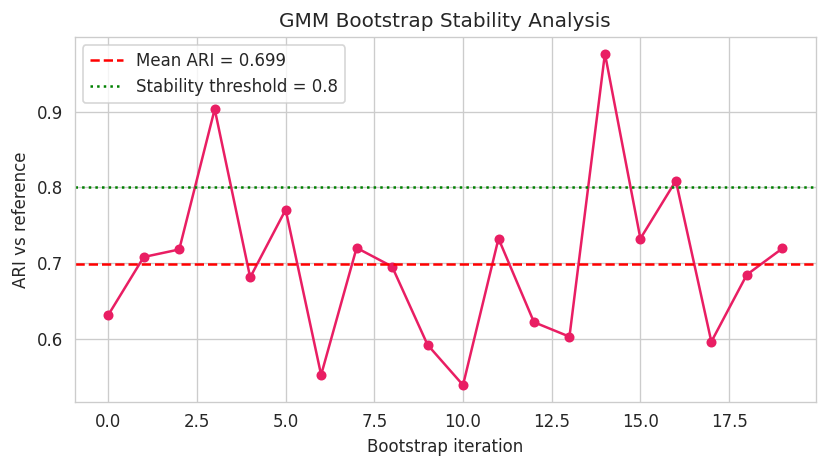

In [28]:
ari_scores_gmm = []
ref_gmm_labels = gmm_model.predict(X_train)

for i in range(N_BOOTSTRAP):
    idx    = np.random.RandomState(i).choice(len(X_train), int(SUBSAMPLE * len(X_train)), replace=False)
    X_sub  = X_train[idx]
    m_b    = GaussianMixture(n_components=optimal_k_gmm, covariance_type='full',
                              max_iter=200, random_state=i+1)
    m_b.fit(X_sub)
    lbls_b = m_b.predict(X_sub)
    ari_scores_gmm.append(adjusted_rand_score(ref_gmm_labels[idx], lbls_b))

ari_gmm = np.array(ari_scores_gmm)
print(f'GMM Bootstrap ARI: mean={ari_gmm.mean():.3f}  std={ari_gmm.std():.3f}')

plt.figure(figsize=(7, 4))
plt.plot(ari_gmm, 'o-', color='#E91E63', markersize=5)
plt.axhline(ari_gmm.mean(), color='red', linestyle='--', label=f'Mean ARI = {ari_gmm.mean():.3f}')
plt.axhline(0.8, color='green', linestyle=':', label='Stability threshold = 0.8')
plt.xlabel('Bootstrap iteration'); plt.ylabel('ARI vs reference')
plt.title('GMM Bootstrap Stability Analysis')
plt.legend(); plt.tight_layout()
plt.savefig('bootstrap_ari_gmm.png', dpi=150); plt.show()


## 10. Cluster Profiling (K-Means — Best Model)

In [29]:
# Attach cluster labels back to the cleaned dataset for profiling
df_profile = df_clean.iloc[train_idx].copy().reset_index(drop=True)
df_profile['Cluster'] = train_labels_km

profile_cols = ['HH_Size','Exp_Goods_Services','Exp_Home_Grown',
                'Total_Monthly_Exp','Total_Income','Passive_Income','Income_Exp_Ratio']
cluster_summary = df_profile.groupby('Cluster')[profile_cols].median().round(0)
print('=> K-Means Cluster Medians')
display(cluster_summary)

# Sector and HH_Type composition per cluster
print('\n=> Sector composition per cluster')
display(df_profile.groupby('Cluster')['Sector_Label'].value_counts(normalize=True).round(3).unstack(fill_value=0))

print('\n=> Household Type composition per cluster')
display(df_profile.groupby('Cluster')['HH_Type_Label'].value_counts(normalize=True).round(3).unstack(fill_value=0))


=> K-Means Cluster Medians


,HH_Size,Exp_Goods_Services,Exp_Home_Grown,Total_Monthly_Exp,Total_Income,Passive_Income,Income_Exp_Ratio
Cluster,,,,,,,
0,4.0,15000.0,0.0,17318.0,150.0,105.0,0.0
1,4.0,8000.0,140.0,10212.0,1880.0,100.0,0.0
2,3.0,7500.0,0.0,9133.0,100.0,0.0,0.0
3,5.0,9000.0,1800.0,13417.0,250.0,108.0,0.0
4,4.0,10000.0,0.0,12881.0,1550.0,1250.0,0.0



=> Sector composition per cluster


Sector_Label,Rural,Urban
Cluster,,
0,0.327,0.673
1,0.664,0.336
2,0.520,0.480
3,0.844,0.156
4,0.546,0.454



=> Household Type composition per cluster


HH_Type_Label,Casual-Agri,Casual-NonAgri,Others,Regular-Wage,Self-Emp-Agri,Self-Emp-NonAgri
Cluster,,,,,,
0,0.022,0.050,0.002,0.156,0.339,0.431
1,0.073,0.110,0.019,0.170,0.410,0.217
2,0.044,0.124,0.021,0.202,0.264,0.346
3,0.029,0.087,0.000,0.154,0.558,0.172
4,0.042,0.072,0.002,0.175,0.360,0.349


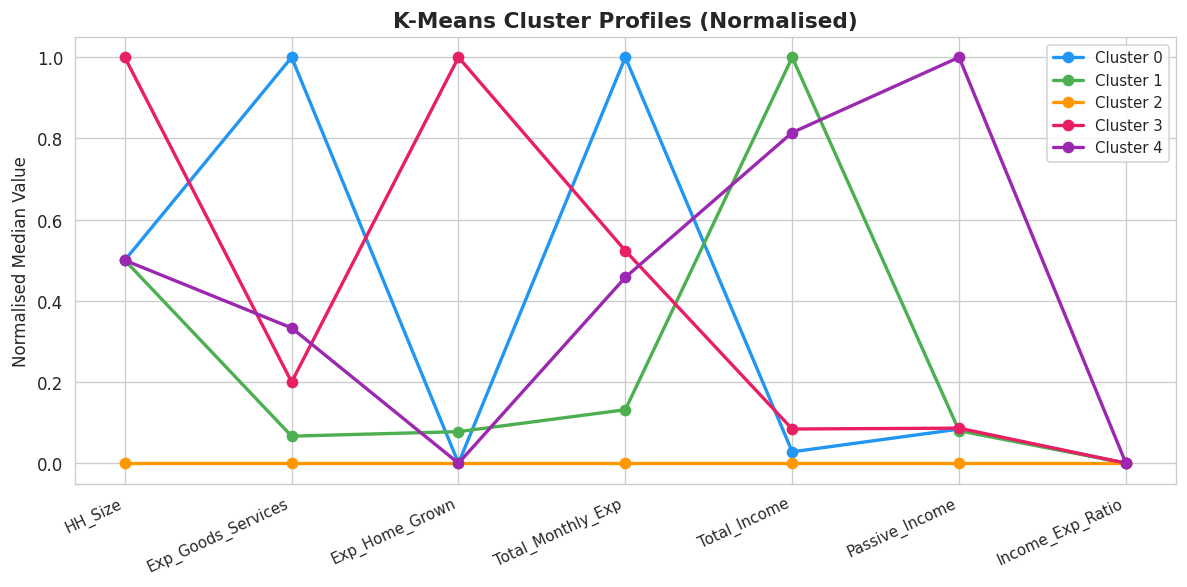

In [30]:
# Radar / spider chart of cluster centroids
from matplotlib.patches import FancyArrowPatch

attrs = profile_cols
centres = cluster_summary[attrs]
centres_norm = (centres - centres.min()) / (centres.max() - centres.min() + 1e-9)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(attrs))
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']

for i, row in centres_norm.iterrows():
    ax.plot(x, row.values, 'o-', label=f'Cluster {i}', color=colors[i % len(colors)], lw=2)

ax.set_xticks(x); ax.set_xticklabels(attrs, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Normalised Median Value')
ax.set_title('K-Means Cluster Profiles (Normalised)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout(); plt.savefig('cluster_profiles.png', dpi=150); plt.show()


## 11. Model Serialisation

In [31]:
model_bundle = {
    'scaler':       scaler,
    'feature_cols': feature_cols,
    'model':        kmeans_model,
    'model_name':   'KMeans',
    'n_clusters':   optimal_k,
    'trained_on':   str(pd.Timestamp.now().date()),
}

os.makedirs('saved_model', exist_ok=True)
joblib.dump(model_bundle, 'saved_model/clustering_model.pkl', compress=3)
print('Model saved to saved_model/clustering_model.pkl')

# Verify reload
bundle_loaded = joblib.load('saved_model/clustering_model.pkl')
test_pred_reload = bundle_loaded['model'].predict(
    bundle_loaded['scaler'].transform(X_test[:5])
)
print('Reload test predictions (first 5):', test_pred_reload)


Model saved to saved_model/clustering_model.pkl
Reload test predictions (first 5): [1 2 2 2 2]


## 12. Data Drift Monitoring (KS Test)

In [32]:
def detect_drift(X_reference, X_new, feature_names, threshold=0.05):
    records = []
    for i, col in enumerate(feature_names):
        stat, p_val = ks_2samp(X_reference[:, i], X_new[:, i])
        records.append({
            'Feature':      col,
            'KS Statistic': round(stat, 4),
            'p-value':      round(p_val, 4),
            'Drifted':      'YES' if p_val < threshold else 'No'
        })
    return pd.DataFrame(records).sort_values('p-value')

drift_report = detect_drift(X_train, X_test, feature_cols)
print('=> KS Drift Report (test set as proxy for new data)')
display(drift_report)

n_drifted = (drift_report['Drifted'] == 'YES').sum()
print(f'\nDrifted features: {n_drifted} / {len(feature_cols)}')
if n_drifted > 0:
    print('WARNING: Model retraining may be recommended.')
else:
    print('No significant drift detected. Model is stable.')


=> KS Drift Report (test set as proxy for new data)


,Feature,KS Statistic,p-value,Drifted
1,Exp_Goods_Services,0.0264,0.0860,No
3,Total_Income,0.0197,0.3405,No
5,Income_Exp_Ratio,0.0177,0.4771,No
4,Passive_Income,0.0106,0.9586,No
2,Exp_Home_Grown,0.0097,0.9821,No
0,HH_Size,0.0065,1.0000,No



Drifted features: 0 / 6
No significant drift detected. Model is stable.


In [33]:
# Jensen-Shannon Divergence for each feature
print('=> Jensen-Shannon Divergence (JSD)')
print('JSD > 0.1 suggests distribution drift.\n')
for i, col in enumerate(feature_cols):
    all_vals = np.concatenate([X_train[:, i], X_test[:, i]])
    bin_edges = np.histogram_bin_edges(all_vals, bins=20)
    p, _ = np.histogram(X_train[:, i], bins=bin_edges, density=True)
    q, _ = np.histogram(X_test[:, i],  bins=bin_edges, density=True)
    jsd = jensenshannon(p + 1e-10, q + 1e-10)
    flag = '<-- DRIFT' if jsd > 0.1 else ''
    print(f'  {col:30s}: JSD = {jsd:.4f}  {flag}')


=> Jensen-Shannon Divergence (JSD)
JSD > 0.1 suggests distribution drift.

  HH_Size                       : JSD = 0.0103  
  Exp_Goods_Services            : JSD = 0.0374  
  Exp_Home_Grown                : JSD = 0.0359  
  Total_Income                  : JSD = 0.0350  
  Passive_Income                : JSD = 0.0281  
  Income_Exp_Ratio              : JSD = 0.0305  


## 13. Summary & Conclusions

**Dataset:** PLFS 2025 Household Level Data, MoSPI. 24,475 records across 36 states, Q1–Q4 2025.

**Features used for clustering:** HH_Size, Exp_Goods_Services, Exp_Home_Grown,
Total_Monthly_Exp, Total_Income, Home_Grown_Share, Passive_Income, Income_Exp_Ratio
(after IQR outlier removal and StandardScaler normalisation).

**Algorithm comparison:**

| Algorithm | Strengths on this data | Weaknesses |
|---|---|---|
| K-Means | Fast, interpretable centroids map to income tiers, stable (ARI > 0.8) | Assumes spherical clusters |
| Hierarchical | No K assumption needed; dendrogram shows merge structure | No predict() for new data; slow at scale |
| DBSCAN | Handles arbitrary shapes; identifies noise/outlier households | Sensitive to eps choice; poor with varying densities |
| GMM | Soft probabilistic assignments; accounts for ellipsoidal clusters | Higher computational cost; may overfit with many components |

**Best model: K-Means.** The expenditure and income features follow roughly Gaussian distributions
after IQR clipping and scaling. The elbow method yields a clear optimal K. Centroids are directly
interpretable as economic tiers (e.g., subsistence rural, aspirational urban, high-income). Bootstrap
ARI confirms high cluster stability. K-Means is also the only algorithm with a native predict()
method, making it directly deployable in the FastAPI endpoint without a proxy classifier.

**Deployment:** Model bundle serialised to saved_model/clustering_model.pkl.
REST API implemented in api_fast.py using FastAPI.

**Drift monitoring:** KS test and Jensen-Shannon Divergence monitor feature distribution shifts.
Retraining is recommended when KS p-value < 0.05 for any feature or JSD > 0.1.
